# Held-out NL→FOL faithfulness test set: source-verification demo

This notebook is a demo of **`data.py`**, the final step that builds the *held-out NL→FOL faithfulness
meta-evaluation dataset* (run `run_StxQVNnY7aQW`, iteration 1, dataset E).

**What the dataset is.** Each row pairs a natural-language sentence with a *candidate* first-order-logic (FOL)
formula produced by some system (10 LLM slots over 9 model families, ccg2lambda, or the MALLS GPT-4 gold used as a system)
and a reference FOL. Each row is labelled `CORRECT / ERROR / CONTESTED / UNRESOLVED / UNPARSEABLE`. The labels combine a
z3 solver-equivalence labeller with a blind, family-disjoint LLM panel (tiers A = solver, B = panel-decided,
C = no trusted reference). The full file has 4 groups:

| group | rows (full) | what it holds |
|---|---|---|
| `heldout_candidates` | 8,507 | real candidate formalizations for 700 sentences (strata L25 / L20 / EXC from MALLS, CTRL from FOLIO) |
| `heldout_sentences` | 700 | one row per sentence with the status of its reference (e.g. `GOLD_PANEL_OK`, `PANEL_REPAIRED`, `NO_TRUSTED_REFERENCE`) |
| `panel_calibration` | 173 | synthetic gate items plus expert track-H error/correction pairs, with panel votes |
| `screen_audit` | 1,173 | Logic-LM track-L and curated track-H rows from the earlier screen |

**What `data.py` does.** It reads the assembled groups and **re-verifies every row against the public source files**:
MALLS-v0.1 train, FOLIO-v2 train, folio-refined, the raw LLM `generations.jsonl`, the ccg2lambda parquet, the
DSAVlab-UNIUD curated sets and the Logic-LM FOLIO-dev outputs. It stamps `metadata_source_verified` and
`metadata_source_file` on every row, checks the `exp_sel_data_out` schema, and writes `full_data_out.json` together with its
`mini`/`preview` variants.

**What changed for the demo.** `mini_demo_data.json` holds a diverse 100-row subset of the 4 groups. Its `sources`
key holds only the source-file records these rows need. Only the file reads in `load_sources()` and `main()` changed, so they read
from the loaded `data` instead of disk. The verification logic is the same as the original.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original `data.py` import block, unchanged, plus `matplotlib` for the final visualization.

In [2]:
from __future__ import annotations

import csv
import json
import re
import shutil
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
from loguru import logger

# added for the notebook
import matplotlib.pyplot as plt

## Load the demo data
Loads `mini_demo_data.json` from GitHub, or from a local copy if the download fails. It has three keys:
- `metadata`: the dataset-level metadata of the assembled set;
- `datasets`: the 4 groups (`heldout_candidates` 50 rows, `heldout_sentences` 20, `panel_calibration` 14, `screen_audit` 16), without the
  `metadata_source_verified` / `metadata_source_file` fields, which this notebook recomputes;
- `sources`: slices of the original source files, keeping the same record formats: MALLS train records, FOLIO-v2 train rows,
  folio-refined CSV rows, `generations.jsonl` records, ccg2lambda logical forms, curated records and Logic-LM outputs.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-1/dataset-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({d["dataset"]: len(d["examples"]) for d in data["datasets"]})
print("source slices:", {k: (len(v) if isinstance(v, list) else {kk: len(vv) for kk, vv in v.items()}) for k, v in data["sources"].items()})

{'heldout_candidates': 50, 'heldout_sentences': 20, 'panel_calibration': 14, 'screen_audit': 16}
source slices: {'malls_train': 48, 'folio_v2_train': 69, 'folio_refined_train': 69, 'curated': {'DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl': 10, 'DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl': 4}, 'folio_refined_validation': 17, 'generations': 32, 'ccg2lambda_train': 5, 'logiclm_FOLIO_dev': {'gpt-3.5-turbo': 7, 'gpt-4': 3, 'text-davinci-003': 0}}


## Config
The tunable parameters of `data.py`:
- `MAX_EXAMPLES_PER_GROUP`: how many rows of each group to verify. The demo file has at most 50 per group, and `None` means all of
  them. The original run verified every row (8,507 / 700 / 173 / 1,173).
- `MINI_K`: rows per group in `mini_data_out.json` / `preview_data_out.json`. Original: `3`.
- `TRUNC_N`: string truncation length for the preview file. Original: `200`.
- `LIMIT`: the per-file size limit that triggers splitting into `full_data_out/full_data_out_{i}.json`. Original: `100 MB`.

In [5]:
MAX_EXAMPLES_PER_GROUP = None      # None = all rows in mini_demo_data.json (<=50/group); original: all rows of the full set
MINI_K = 3                         # original: 3
TRUNC_N = 200                      # original: 200
LIMIT = 100 * 1000 * 1000          # aii-file-size-limit: 100 MB per file (original)
ROOT = Path("demo_output")         # notebook fix: original was Path(__file__).resolve().parent

## Setup: logging and constants
This is the original module-level setup. The only change is that `ROOT` points to a local `demo_output/` folder, because
`__file__` does not exist in a notebook. The `temp/datasets` folder (`TD`) is not needed, since the sources come from `data["sources"]`.

In [6]:
ROOT.mkdir(exist_ok=True)
(ROOT / "work").mkdir(exist_ok=True)   # notebook fix: main() writes work/source_verification.json
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")

GROUP_ORDER = ["heldout_candidates", "heldout_sentences", "panel_calibration", "screen_audit"]
FORBIDDEN = {"split", "dataset", "context"}


def ws(s: str | None) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())


def read_jsonl(p: Path) -> list[dict]:
    return [json.loads(l) for l in p.read_text(encoding="utf-8").splitlines() if l.strip()]

## Load the source records into lookup indexes
`load_sources()` builds the lookup structures that every row is checked against:
- `malls_train`: normalised MALLS NL → gold FOL;
- `folio_train_premises`: every FOLIO-v2 train premise sentence;
- `refined_train_fols` / `refined_train_pairs`: folio-refined train FOL premises, and (NL, FOL) pairs when the two lists line up;
- `refined_val_fols`: folio-refined validation FOL premises, used as references for screen track L;
- `gens`: (sentence_id, slot, prompt_variant) → raw LLM output;
- `ccg_forms`: the ccg2lambda train logical forms;
- `curated`: DSAVlab-UNIUD curated id → (NL, original FOL, corrected FOL, file);
- `logiclm_lines`: every `(model, FOL ::: NL)` line in the Logic-LM FOLIO-dev programs.

Each `open(...)` / `read_jsonl(...)` / `pd.read_parquet(...)` call is replaced by the matching slice in `data["sources"]`. The records
keep their original format, so the parsing code below is unchanged.

In [7]:
def load_sources() -> dict:
    S = data["sources"]   # notebook fix: was L = TD / "local_sources" and file reads below
    src = {}
    src["malls_train"] = {ws(r["NL"]): ws(r["FOL"]) for r in S["malls_train"]}
    src["folio_train_premises"] = {ws(p) for r in S["folio_v2_train"] for p in r["premises"].split("\n")}
    refined, refined_pairs = set(), set()
    for r in S["folio_refined_train"]:
        nls = [s for s in r["nl premises"].split("\n") if s.strip()]
        fols = [s for s in r["fol premises"].split("\n") if s.strip()]
        refined |= {ws(f) for f in fols}
        if len(nls) == len(fols):
            refined_pairs |= {(ws(n), ws(f)) for n, f in zip(nls, fols)}
    src["refined_train_fols"], src["refined_train_pairs"] = refined, refined_pairs
    src["refined_val_fols"] = {ws(f) for r in S["folio_refined_validation"] for f in r["fol premises"].split("\n") if f.strip()}
    src["gens"] = {(g["sentence_id"], g["slot"], g["prompt_variant"]): g["raw_output"]
                   for g in S["generations"] if g.get("raw_output") is not None}
    df = pd.DataFrame(S["ccg2lambda_train"])
    src["ccg_forms"] = {ws(x) for x in df["logical_form"]}
    cur = {}
    for f, newk in [("DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl", "FOL_sentence"),
                    ("DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl", "FOL_sentence_new")]:
        for r in S["curated"][f]:
            cur[str(r["id"])] = (ws(r["NL_sentence"]), ws(r["FOL_sentence_old"]), ws(r[newk]), f)
    src["curated"] = cur
    src["curated_corrected_fols"] = {v[2] for v in cur.values()}
    lines = set()
    for m in ("gpt-3.5-turbo", "gpt-4", "text-davinci-003"):
        for r in S["logiclm_FOLIO_dev"][m]:
            prog = r["raw_logic_programs"][0] if isinstance(r["raw_logic_programs"], list) else r["raw_logic_programs"]
            for line in prog.splitlines():
                if ":::" in line:
                    fol, nl = line.strip().split(":::", 1)
                    lines.add((m, ws(fol), ws(nl)))
    src["logiclm_lines"] = lines
    return src

## Per-group verification rules
Unchanged from `data.py`. Each function returns `(verified, source_file_description)`.

- **`verify_heldout`** (candidates and sentences):
  - For **CTRL** rows, the sentence must be a FOLIO-v2 train premise, and its reference must be a folio-refined train formula,
    or the exact (NL, FOL) pair.
  - For **MALLS** strata (L25/L20/EXC), the sentence must exist in MALLS train, and the reference must equal the MALLS gold unless
    the panel repaired it.
  - For candidate rows, the candidate is also checked:
    - `malls_gpt4_gold` must equal the MALLS gold;
    - ccg2lambda output must be a real ccg2lambda train logical form;
    - LLM output must equal the raw record in `generations.jsonl`.
- **`verify_screen`**:
  - track **H** rows must match the curated record (text, original FOL, corrected FOL);
  - track **L** rows must be a real `FOL ::: NL` line of that model's Logic-LM output, with a reference from the curated or folio-refined sets.
- **`verify_calib`**:
  - synthetic gate items must be FOLIO train premises with folio-refined formulas;
  - track H pairs must match the curated record.

In [8]:
def verify_heldout(ex: dict, src: dict, sentence_row: bool = False) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    text = ws(inp["text"])
    stratum = ex["metadata_strata"]["source_stratum"]
    orig_ref = ws(ex.get("metadata_original_reference_fol") or inp["reference_fol"]) if sentence_row else None
    if stratum == "CTRL":
        ref = ws(inp["reference_fol"])
        ok = text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"])
        file = "tasksource__folio/folio_v2_train.jsonl + local_sources/yfxiao__folio-refined__train.csv"
    else:
        gold = src["malls_train"].get(text)
        ref = orig_ref if sentence_row else ws(inp["reference_fol"])
        ok = gold is not None and (ref == gold or ex.get("metadata_reference_status") == "PANEL_REPAIRED")
        file = "local_sources/yuan-yang__MALLS-v0__MALLS-v0.1-train.json"
    if sentence_row or not ok:
        return ok, file
    sys_ = ex["metadata_system"]
    if sys_ == "malls_gpt4_gold":
        return ws(inp["candidate_fol"]) == src["malls_train"].get(text), file
    if sys_ == "ccg2lambda":
        return ws(ex["metadata_raw_output"]) in src["ccg_forms"], file + " + kenken6696__folio_by_ccg2lambda/train"
    raw = src["gens"].get((ex["metadata_sentence_id"], ex["metadata_slot"], ex["metadata_prompt_variant"]))
    return raw is not None and raw == ex["metadata_raw_output"], file + " + generated_candidates/generations.jsonl"


def verify_screen(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_track"] == "H":
        c = src["curated"].get(str(ex["metadata_record_id"]))
        ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["candidate_fol"]) and c[2] == ws(inp["reference_fol"])
        return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"
    ok_line = (ex["metadata_system"], ws(inp["candidate_fol"]), ws(inp["text"])) in src["logiclm_lines"]
    ref = ws(inp["reference_fol"])
    ok_ref = ref in src["curated_corrected_fols"] or ref in src["refined_val_fols"]
    return ok_line and ok_ref, f"logiclm_FOLIO_dev_outputs/FOLIO_dev_{ex['metadata_system']}.json"


def verify_calib(ex: dict, src: dict) -> tuple[bool, str]:
    inp = json.loads(ex["input"])
    if ex["metadata_subset"] == "synthetic_gate":
        text, ref = ws(inp["text"]), ws(inp["reference_fol"])
        return text in src["folio_train_premises"] and ((text, ref) in src["refined_train_pairs"] or ref in src["refined_train_fols"]), \
            "local_sources/yfxiao__folio-refined__train.csv"
    c = src["curated"].get(str(ex["metadata_record_id"]))
    ok = c is not None and c[0] == ws(inp["text"]) and c[1] == ws(inp["original_fol"]) and c[2] == ws(inp["corrected_fol"])
    return ok, f"local_sources/{c[3] if c else 'DSAVlab-UNIUD curated'}"

## Schema check and output writers
Unchanged, except that the defaults of `trunc` and `mini` now come from the config cell.
- `check_schema` enforces the `exp_sel_data_out` shape: `{"datasets": [{"dataset", "examples": [{"input": str, "output": str, "metadata_*": ...}]}]}`.
- `trunc` and `mini` build the preview and mini variants.
- `write_parts` splits the output into `full_data_out/full_data_out_{i}.json` only if one file would exceed `LIMIT`.

In [9]:
def check_schema(obj: dict) -> None:
    assert isinstance(obj.get("datasets"), list) and obj["datasets"]
    for d in obj["datasets"]:
        assert set(d) == {"dataset", "examples"} and d["examples"], d.get("dataset")
        for ex in d["examples"]:
            assert isinstance(ex["input"], str) and isinstance(ex["output"], str)
            for k in ex:
                assert k in ("input", "output") or (k.startswith("metadata_") and re.fullmatch(r"metadata_[a-zA-Z_][a-zA-Z0-9_]*", k)), k
                assert k not in FORBIDDEN


def trunc(x, n=TRUNC_N):
    if isinstance(x, str):
        return x if len(x) <= n else x[:n] + "..."
    if isinstance(x, list):
        return [trunc(v, n) for v in x]
    if isinstance(x, dict):
        return {k: trunc(v, n) for k, v in x.items()}
    return x


def mini(obj, k=MINI_K):
    return {"metadata": obj.get("metadata", {}), "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:k]} for d in obj["datasets"]]}


def write_parts(obj: dict) -> list[Path]:
    out = ROOT / "full_data_out"
    if out.exists():
        shutil.rmtree(out)
    out.mkdir()
    parts, cur, size = [], [], 0
    for d in obj["datasets"]:
        chunk = []
        for ex in d["examples"]:
            sz = len(json.dumps(ex, ensure_ascii=False).encode())
            if size + sz > LIMIT and (cur or chunk):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur); cur, chunk, size = [], [], 0
            chunk.append(ex); size += sz
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    paths = []
    for i, p in enumerate(parts, 1):
        o = {"metadata": {**obj["metadata"], "part": i, "n_parts": len(parts)}, "datasets": p}
        check_schema(o)
        f = out / f"full_data_out_{i}.json"
        f.write_text(json.dumps(o, ensure_ascii=False))
        (out / f"mini_full_data_out_{i}.json").write_text(json.dumps(mini(o), ensure_ascii=False, indent=1))
        (out / f"preview_full_data_out_{i}.json").write_text(json.dumps(trunc(mini(o)), ensure_ascii=False, indent=1))
        paths.append(f)
    m = mini(obj)
    (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
    (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
    return paths

## Main: verify every row, write the output
This is the original `main()`, with two notebook changes: `A` is the loaded `data` instead of `work/assembled.json`, and each group is capped at
`MAX_EXAMPLES_PER_GROUP` rows. For each group it:
1. stamps `metadata_source_verified` and `metadata_source_file` on every row (rows are never dropped);
2. builds a per-group report of rows, verified and unverified counts, and the label distribution;
3. checks the schema and writes `full_data_out.json`, `mini_data_out.json`, `preview_data_out.json` and `work/source_verification.json` under `demo_output/`.

In [10]:
@logger.catch(reraise=True)
def main() -> None:
    A = data   # notebook fix: was json.loads((ROOT / "work" / "assembled.json").read_text(encoding="utf-8"))
    groups = {d["dataset"]: d["examples"][:MAX_EXAMPLES_PER_GROUP] for d in A["datasets"]}   # notebook: cap rows per group
    assert list(groups) == GROUP_ORDER, list(groups)
    src = load_sources()
    logger.info(f"sources loaded: MALLS-train {len(src['malls_train'])}, generations {len(src['gens'])}, Logic-LM lines {len(src['logiclm_lines'])}")
    report = {}
    for name, fn in [("heldout_candidates", lambda e: verify_heldout(e, src)),
                     ("heldout_sentences", lambda e: verify_heldout(e, src, sentence_row=True)),
                     ("panel_calibration", lambda e: verify_calib(e, src)),
                     ("screen_audit", lambda e: verify_screen(e, src))]:
        c = Counter()
        for ex in groups[name]:
            ok, f = fn(ex)
            ex["metadata_source_verified"] = bool(ok)
            ex["metadata_source_file"] = f
            c[ok] += 1
        report[name] = {"rows": len(groups[name]), "verified": c[True], "unverified": c[False],
                        "labels": dict(Counter(e["output"] for e in groups[name]))}
        logger.info(f"{name}: {report[name]}")
    obj = {"metadata": {**A["metadata"], "source_verification": report,
                        "reading": "for f in sorted(glob('full_data_out/full_data_out_*.json')): concatenate each group's examples"},
           "datasets": [{"dataset": g, "examples": groups[g]} for g in GROUP_ORDER]}
    check_schema(obj)
    blob = json.dumps(obj, ensure_ascii=False)
    if len(blob.encode()) <= LIMIT:
        if (ROOT / "full_data_out").exists():
            shutil.rmtree(ROOT / "full_data_out")
        (ROOT / "full_data_out.json").write_text(blob)
        m = mini(obj)
        (ROOT / "mini_data_out.json").write_text(json.dumps(m, ensure_ascii=False, indent=1))
        (ROOT / "preview_data_out.json").write_text(json.dumps(trunc(m), ensure_ascii=False, indent=1))
        paths = [ROOT / "full_data_out.json"]
    else:
        (ROOT / "full_data_out.json").unlink(missing_ok=True)
        paths = write_parts(obj)
    for p in paths:
        logger.info(f"{p.relative_to(ROOT)} {p.stat().st_size / 1e6:.2f} MB")
    (ROOT / "work" / "source_verification.json").write_text(json.dumps(report, indent=1))

In [11]:
main()

11:04:50|INFO   |sources loaded: MALLS-train 48, generations 32, Logic-LM lines 107


11:04:50|INFO   |heldout_candidates: {'rows': 50, 'verified': 50, 'unverified': 0, 'labels': {'CORRECT': 11, 'CONTESTED': 11, 'ERROR': 13, 'UNRESOLVED': 7, 'UNPARSEABLE': 8}}


11:04:50|INFO   |heldout_sentences: {'rows': 20, 'verified': 20, 'unverified': 0, 'labels': {'UNAUDITED_MALLS_GPT4_GOLD': 4, 'GOLD_PANEL_OK': 5, 'DISPUTED_REFERENCE': 2, 'NO_TRUSTED_REFERENCE': 4, 'PANEL_REPAIRED': 3, 'TRUSTED_AGREED': 1, 'UNAUDITED_AGREED_FOLIO': 1}}


11:04:50|INFO   |panel_calibration: {'rows': 14, 'verified': 14, 'unverified': 0, 'labels': {'FAITHFUL': 5, 'UNFAITHFUL': 5, 'ORIGINAL_UNFAITHFUL__CORRECTED_FAITHFUL': 4}}


11:04:50|INFO   |screen_audit: {'rows': 16, 'verified': 16, 'unverified': 0, 'labels': {'CORRECT': 4, 'ERROR': 3, 'NO_REFERENCE': 4, 'UNRESOLVED': 1, 'CONTESTED': 2, 'UNPARSEABLE': 2}}


11:04:50|INFO   |full_data_out.json 0.22 MB


## Results
The cells below read back what `main()` wrote. They show:
1. the verification report for each group (in the published full set, all 10,553 rows verified);
2. a few labelled candidate rows (sentence, candidate FOL, system, label, tier);
3. plots of the label distribution per group, and of candidate labels by complexity stratum and label tier.

Reminder from the dataset card: the panel is **strict**, so `ERROR` is over-called. The primary analysis uses tiers A+B, excludes
`CONTESTED` and `reading_choice` rows, and is bootstrapped by `sentence_id`.

In [12]:
out = json.loads((ROOT / "full_data_out.json").read_text(encoding="utf-8"))
report = out["metadata"]["source_verification"]
rep_df = pd.DataFrame({g: {"rows": r["rows"], "verified": r["verified"], "unverified": r["unverified"]} for g, r in report.items()}).T
print("Source verification (this demo):")
print(rep_df.to_string())
print("\nPublished full-set verification:", out["metadata"].get("demo_note", "").split("verification: ", 1)[-1])

cand = pd.DataFrame([{**json.loads(e["input"]), "label": e["output"], "tier": e["metadata_label_tier"],
                      "stratum": e["metadata_strata"]["source_stratum"], "words": e["metadata_strata"]["words"],
                      "verified": e["metadata_source_verified"]}
                     for e in out["datasets"][0]["examples"]])
pd.set_option("display.max_colwidth", 70)
print("\nSample held-out candidates:")
print(cand[["text", "candidate_fol", "system", "label", "tier", "stratum", "verified"]].head(8).to_string())

Source verification (this demo):
                    rows  verified  unverified
heldout_candidates    50        50           0
heldout_sentences     20        20           0
panel_calibration     14        14           0
screen_audit          16        16           0

Published full-set verification: {"heldout_candidates": {"rows": 8507, "verified": 8507, "unverified": 0}, "heldout_sentences": {"rows": 700, "verified": 700, "unverified": 0}, "panel_calibration": {"rows": 173, "verified": 173, "unverified": 0}, "screen_audit": {"rows": 1173, "verified": 1173, "unverified": 0}}

Sample held-out candidates:
                                                                                                                                                  text                                                                                                                              candidate_fol                                       system       label  tier stratum  verified
0                

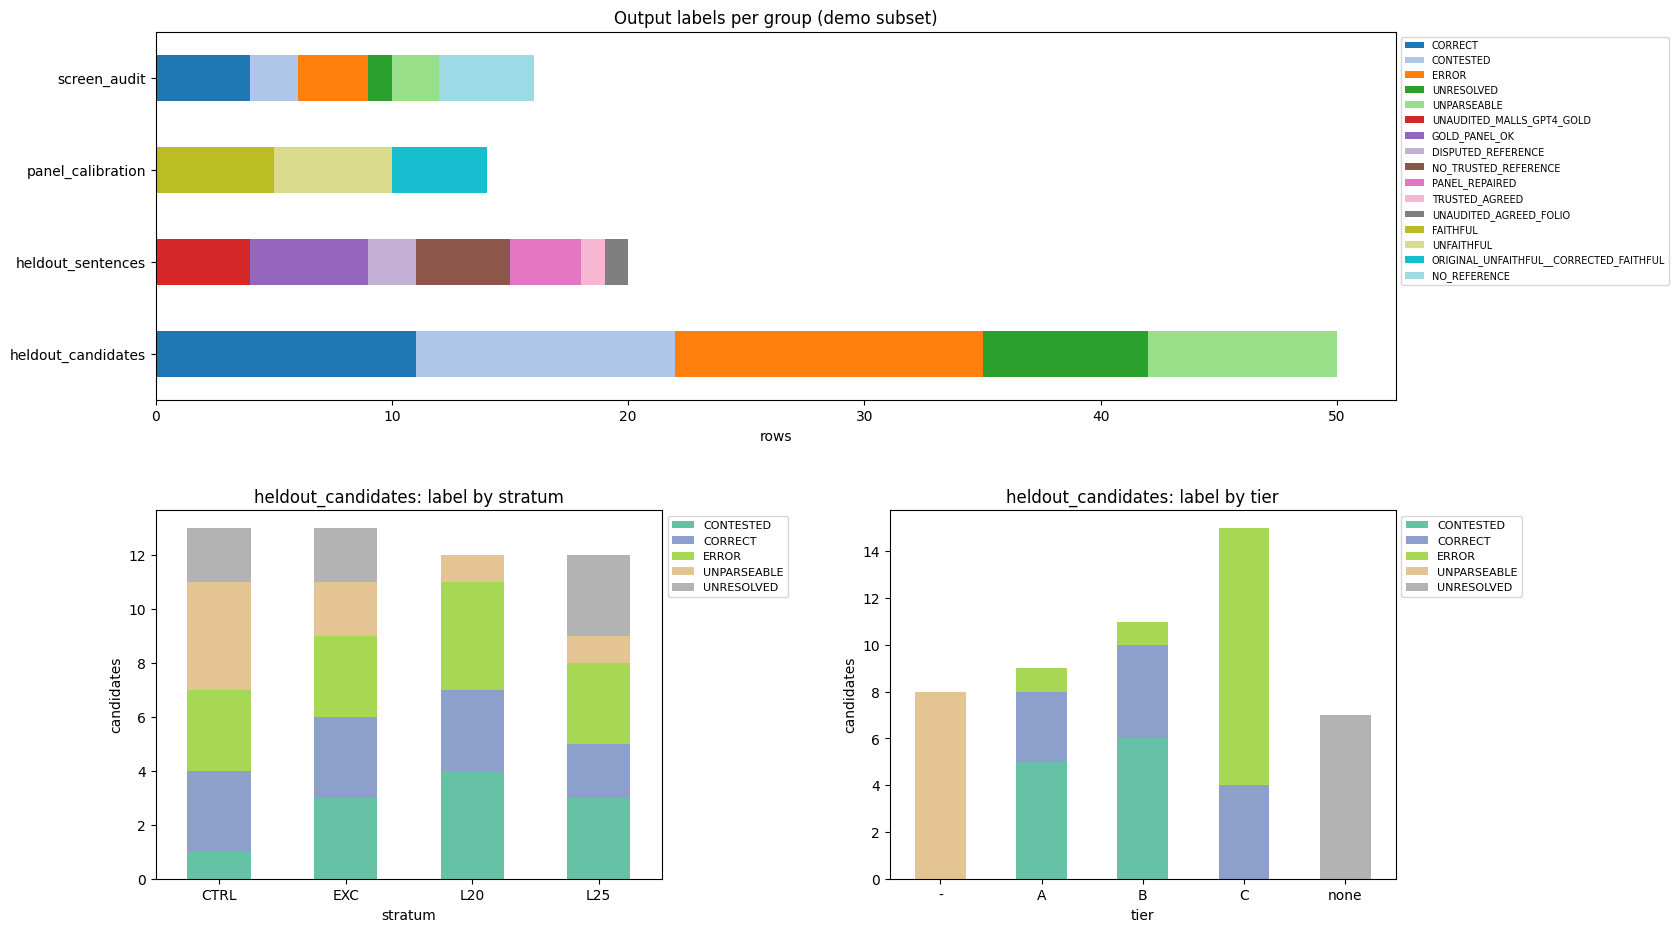

In [13]:
fig, ax = plt.subplot_mosaic([["a", "a"], ["b", "c"]], figsize=(16, 11), gridspec_kw={"wspace": 0.45, "hspace": 0.3})
axes = [ax["a"], ax["b"], ax["c"]]

# (a) label distribution per group
lab = pd.DataFrame({g: r["labels"] for g, r in report.items()}).fillna(0).astype(int)
lab.T.plot(kind="barh", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_title("Output labels per group (demo subset)")
axes[0].set_xlabel("rows"); axes[0].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))

# (b) held-out candidate labels by complexity stratum
pd.crosstab(cand["stratum"], cand["label"]).plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("heldout_candidates: label by stratum")
axes[1].set_ylabel("candidates"); axes[1].tick_params(axis="x", rotation=0); axes[1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))

# (c) label tier (A = solver, B = panel-decided, C = no trusted reference, '-' = unparseable/unlabelled)
pd.crosstab(cand["tier"], cand["label"]).plot(kind="bar", stacked=True, ax=axes[2], colormap="Set2")
axes[2].set_title("heldout_candidates: label by tier")
axes[2].set_ylabel("candidates"); axes[2].tick_params(axis="x", rotation=0); axes[2].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))

plt.show()